# 信頼バンドの根探索 (`find_confidence_band`)

等間隔グリッドの代わりに、ブラケット＋幾何二分法でバンドの上下端を直接探す例。
最も広い 2σ で外側をブラケットし、各レベル (1σ/90%/2σ) の端を入れ子で詰める。

- `num_pseudo_data`: ブラケット段階の擬似データ数（粗くてよい）
- `n_pseudo_edge`: 端の二分法で使う擬似データ数（cutoff のノイズを抑えるため大きめ）
- `seed`: 固定すると各点が再現可能になり、二分法のジッターが減る

In [1]:
from neutrino_analysis_band import NeutrinoAnalysis


Optimization Complete.
Minimum chi-squared: 2.468163639986362e-05
Plot saved as T20/scenario_bkg_a/flux_comparison_bkg_a.pdf


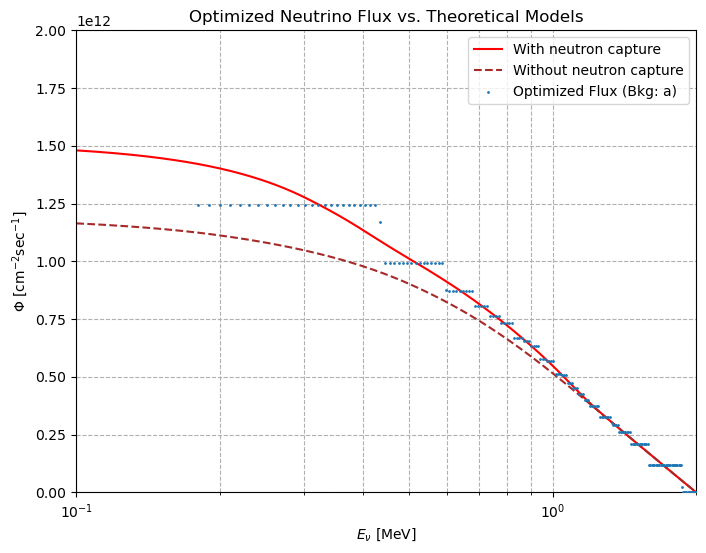

In [7]:
a = NeutrinoAnalysis(background_scenario='a', intervals='180',
                     GeV=1e16, solver='osqp', T=20)
a.optimize(a.data_vector)   # ベストフィットを先に求める (self.result を埋める)
result_a = a.optimize(a.data_vector)
print("\nOptimization Complete.")
print(f"Minimum chi-squared: {result_a.fun / a.c}")
# 3. Plot the primary result: the optimized flux vs. theory.
a.plot_flux_comparison(save = True)

## 複数インデックスのバンドを保存して重ねる

1. インデックスごとに `find_and_save_band` を実行し、`bands/` 配下に 1 ファイルずつ JSON で保存する。
2. `plot_flux_with_bands` で保存済みファイルを読み込み、`optimize` の最適フラックス（散布図）の上に各インデックスのバンドを誤差棒として重ねる。

`save_band` / `load_band` は JSON 形式（人が読める）。バンドの中心は保存時の `self.result.x[index]` なので、同じ `optimize` 結果の散布図とちょうど重なる。

In [ ]:
# 自動で T 別フォルダに保存（outdir 省略可）
# → T3/scenario_bkg_flat/bands/band_bkgflat_idx000.json

# 複数インデックスでバンドを作り、インデックスごとに 1 ファイルへ保存
# 保存先は ./bands/band_bkg<scenario>_idx<NNN>.json
indices = [1, 2, 3, 4, 5, 8, 13, 16, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 167]     # 走らせたいインデックス

for idx in indices:
    print(f'=== index {idx} ===')
    a.find_and_save_band(
        idx,
        outdir='T20/scenario_bkg_a/bands',
        levels=(0.678, 0.954),
        num_pseudo_data=50,
        n_pseudo_edge=500,
        step=1.5,
        rel_tol=0.03,
        seed=42,
        n_jobs=1,
        verbose=True,
    )

=== index 1 ===
[band idx=1] v0=1.2442e+12 (phys), bracketing with step=1.5
  upper bracket: 3.1887e+13
  lower bracket: 8.2947e+11
  level 0.678: [1.0289e+12, 1.9456e+13] (phys)
  level 0.954: [9.5360e+11, 2.8453e+13] (phys)
Band saved as T20/scenario_bkg_a/bands/band_bkga_idx001.json
=== index 2 ===
[band idx=2] v0=1.2442e+12 (phys), bracketing with step=1.5
  upper bracket: 2.1258e+13
  lower bracket: 8.2947e+11
  level 0.678: [1.0289e+12, 1.1813e+13] (phys)
  level 0.954: [9.5360e+11, 1.6844e+13] (phys)
Band saved as T20/scenario_bkg_a/bands/band_bkga_idx002.json
=== index 3 ===
[band idx=3] v0=1.2442e+12 (phys), bracketing with step=1.5
  upper bracket: 1.4172e+13
  lower bracket: 8.2947e+11
  level 0.678: [1.0289e+12, 8.0901e+12] (phys)
  level 0.954: [9.5360e+11, 1.1390e+13] (phys)
Band saved as T20/scenario_bkg_a/bands/band_bkga_idx003.json
=== index 4 ===
[band idx=4] v0=1.2442e+12 (phys), bracketing with step=1.5
  upper bracket: 9.4481e+12
  lower bracket: 8.2947e+11
  level

In [ ]:
# 保存したバンドを読み込んで optimize 結果の上に重ねる
# band_files はグロブパターンでも、明示的なリストでもよい
a.plot_flux_with_bands(
    f'scenario_bkg_b/bands/band_bkg{a.background_scenario}_idx*.json',
    levels=(0.678, 0.954),   # 表示するレベル (省略すると保存済み全レベル)
    save=True,
    ylim=(0, 3e13),                # 高フラックス側の裾まで見えるように
)
import matplotlib.pyplot as plt
#plt.yscale('log')
plt.ylim(0, 2e12)
plt.show()

In [ ]:
# 保存したバンドを読み込んで optimize 結果の上に重ねる
# band_files はグロブパターンでも、明示的なリストでもよい
a.plot_flux_with_bands(
    f'scenario_bkg_b/bands/band_bkg{a.background_scenario}_idx*.json',
    levels=(0.678, 0.954),   # 表示するレベル (省略すると保存済み全レベル)
    save=True,
    ylim=(0, 3e13),                # 高フラックス側の裾まで見えるように
)
import matplotlib.pyplot as plt
plt.yscale('log')
plt.ylim(1e11, 1e14)
plt.show()